In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv('injection_molding.csv')
df.drop(columns=['timestamp'], inplace=True)
df.head(1)

,mold_name,material_name,machine_tonnage,cycle_number,hopper_temp,nozzle_temp,H1,H2,H3,mold_core_temp,...,total_cycle_time,Hopper_State,Barrel_Heater_State,Screw_State,Injection_Unit_State,Hydraulic_System_State,Clamp_Unit_State,Mold_State,Cooling_System_State,Ejector_System_State
0,Smart Router Enclosure,"ABS (Flame Retardant, Medium Flow)",180,1,45,230,225,211,201,67,...,24.61,0,0,0,0,0,0,0,0,0


In [3]:
target = ['Hopper_State','Barrel_Heater_State', 'Screw_State', 'Injection_Unit_State','Hydraulic_System_State', 
               'Clamp_Unit_State', 'Mold_State','Cooling_System_State', 'Ejector_System_State']  
sensor = [i for i in df.columns if i not in target]
sensor.remove('mold_name')
sensor.remove('material_name')
len(sensor)

34

In [4]:
def find_correlation(corr, threshold=0.95):
    """Iteratively drop the more globally-redundant column of the most-correlated
    remaining pair, until no pair exceeds threshold. Avoids over-pruning chains."""
    corr = corr.abs().copy()
    vals = corr.values.copy()
    np.fill_diagonal(vals, 0)  # ignore self-correlation
    corr = pd.DataFrame(vals, index=corr.index, columns=corr.columns)
    to_drop = []
    while True:
        max_corr = corr.values.max()
        if max_corr <= threshold or corr.shape[0] <= 1:
            break
        i, j = np.unravel_index(np.argmax(corr.values), corr.shape)
        col_i, col_j = corr.index[i], corr.columns[j]
        # drop whichever has the higher average correlation with everything else remaining
        drop_col = col_i if corr[col_i].mean() > corr[col_j].mean() else col_j
        to_drop.append(drop_col)
        corr = corr.drop(index=drop_col, columns=drop_col)
    return to_drop

# correlation-based pruning of redundant raw sensor columns
corr = df[sensor].corr()
to_drop = find_correlation(corr, threshold=0.95)
kept_numeric_cols = [c for c in sensor if c not in to_drop]
df.drop(columns=to_drop, inplace=True)
print(f"Dropped {len(to_drop)} redundant (|r|>0.95) columns, kept {len(kept_numeric_cols)}:")
print(kept_numeric_cols)

Dropped 18 redundant (|r|>0.95) columns, kept 16:
['cycle_number', 'hopper_temp', 'H1', 'mold_cavity_temp', 'inj_speed1', 'actual_inj_pressure', 'vp_transition', 'holding_pressure_stage2', 'back_pressure', 'decompression_speed', 'decompression_distance', 'cushion_size', 'clamp_force', 'mold_protection_pressure', 'ejection_stroke', 'part_weight']


In [5]:
df.columns

Index(['mold_name', 'material_name', 'cycle_number', 'hopper_temp', 'H1',
       'mold_cavity_temp', 'inj_speed1', 'actual_inj_pressure',
       'vp_transition', 'holding_pressure_stage2', 'back_pressure',
       'decompression_speed', 'decompression_distance', 'cushion_size',
       'clamp_force', 'mold_protection_pressure', 'ejection_stroke',
       'part_weight', 'Hopper_State', 'Barrel_Heater_State', 'Screw_State',
       'Injection_Unit_State', 'Hydraulic_System_State', 'Clamp_Unit_State',
       'Mold_State', 'Cooling_System_State', 'Ejector_System_State'],
      dtype='str')

# Train Test  Split

In [6]:
import pandas as pd 
train_list = []
val_list = []
test_list = []
# Sort first
df = df.sort_values(['mold_name', 'cycle_number']).reset_index(drop=True)
for mold_id, group in df.groupby('mold_name'):
    n = len(group)
    train_end = int(n * 0.70)
    val_end = int(n * 0.85)
    train_list.append(group.iloc[:train_end])
    val_list.append(group.iloc[train_end:val_end])
    test_list.append(group.iloc[val_end:])
train_df = pd.concat(train_list).reset_index(drop=True)
val_df = pd.concat(val_list).reset_index(drop=True)
test_df = pd.concat(test_list).reset_index(drop=True)
print(f"Train: {train_df.shape}")
print(f"Validation: {val_df.shape}")
print(f"Test: {test_df.shape}")

Train: (28000, 27)
Validation: (6000, 27)
Test: (6000, 27)


In [7]:
window = 5
temp_pressure  = ['hopper_temp', 'H1', 'mold_cavity_temp', 'inj_speed1','holding_pressure_stage2', 'back_pressure', 'decompression_speed','mold_protection_pressure', 'ejection_stroke', 'part_weight']

def add_engineered_features(data, window=window, temp_pressure=temp_pressure, kept_numeric_cols=kept_numeric_cols):
    data = data.sort_values(['mold_name', 'cycle_number']).reset_index(drop=True)
    grp = data.groupby('mold_name')

    # rolling mean & std
    roll_mean = grp[temp_pressure].rolling(window, min_periods=1).mean().droplevel(0)
    roll_mean.columns = [f'{c}_roll_mean' for c in temp_pressure]

    roll_std = grp[temp_pressure].rolling(window, min_periods=1).std().droplevel(0)
    roll_std.columns = [f'{c}_roll_std' for c in temp_pressure]

    # delta
    delta = grp[kept_numeric_cols].diff()
    delta.columns = [f'{c}_delta' for c in kept_numeric_cols]

    eng = pd.concat([roll_mean, roll_std, delta], axis=1).sort_index().fillna(0.0)
    return pd.concat([data, eng], axis=1)

train_df = add_engineered_features(train_df)
val_df = add_engineered_features(val_df)
test_df = add_engineered_features(test_df)

print(f"Train: {train_df.shape}")
print(f"Validation: {val_df.shape}")
print(f"Test: {test_df.shape}")

Train: (28000, 63)
Validation: (6000, 63)
Test: (6000, 63)


In [8]:
#ohe on mold id
def add_mold_dummies(data):
    enc = pd.get_dummies(data['mold_name'], prefix='mold_name', dtype=int)
    return pd.concat([enc,data], axis=1)

train_df = add_mold_dummies(train_df)
val_df = add_mold_dummies(val_df)
test_df = add_mold_dummies(test_df)

In [9]:
train_df.columns

Index(['mold_name_Blood Filtration Housing', 'mold_name_Engine Mount Bracket',
       'mold_name_Rectangular Food Container',
       'mold_name_Smart Router Enclosure', 'mold_name', 'material_name',
       'cycle_number', 'hopper_temp', 'H1', 'mold_cavity_temp', 'inj_speed1',
       'actual_inj_pressure', 'vp_transition', 'holding_pressure_stage2',
       'back_pressure', 'decompression_speed', 'decompression_distance',
       'cushion_size', 'clamp_force', 'mold_protection_pressure',
       'ejection_stroke', 'part_weight', 'Hopper_State', 'Barrel_Heater_State',
       'Screw_State', 'Injection_Unit_State', 'Hydraulic_System_State',
       'Clamp_Unit_State', 'Mold_State', 'Cooling_System_State',
       'Ejector_System_State', 'hopper_temp_roll_mean', 'H1_roll_mean',
       'mold_cavity_temp_roll_mean', 'inj_speed1_roll_mean',
       'holding_pressure_stage2_roll_mean', 'back_pressure_roll_mean',
       'decompression_speed_roll_mean', 'mold_protection_pressure_roll_mean',
       'eje

In [10]:
# scaling numeric features
scaler = StandardScaler()
id_cat_cols = ['mold_name', 'material_name']
mold_dummy_cols = [c for c in train_df.columns if c.startswith('mold_name_')]

exclude_cols = id_cat_cols + target + mold_dummy_cols

numeric_cols = train_df.select_dtypes(include=np.number).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in exclude_cols]

train_df[numeric_cols] = scaler.fit_transform(train_df[numeric_cols])
val_df[numeric_cols] = scaler.transform(val_df[numeric_cols])
test_df[numeric_cols] = scaler.transform(test_df[numeric_cols])

In [11]:
train_df.drop(columns=['mold_name','material_name'],inplace=True)
val_df.drop(columns=['mold_name','material_name'],inplace=True)
test_df.drop(columns=['mold_name','material_name'],inplace=True)

In [12]:
def reorder_target_last(data, target=target):
    cols = [c for c in data.columns if c not in target] + target
    return data[cols]

train_df = reorder_target_last(train_df)
val_df = reorder_target_last(val_df)
test_df = reorder_target_last(test_df)

X_train, y_train = train_df.drop(columns=target), train_df[target]
X_val, y_val = val_df.drop(columns=target), val_df[target]
X_test, y_test = test_df.drop(columns=target), test_df[target]

# Anomaly/ Novelty detection

Same 5 algorithms as `final_model.ipynb`'s anomaly-detection section -- **Isolation Forest, ECOD, COPOD, LOF, Autoencoder** -- fit independently per subsystem target.

**Difference from `final_model.ipynb`:** instead of restricting each target's detectors to only the sensor column(s) that `synthetic_data_eda.ipynb` showed actually move with that subsystem's state, every target's detectors here see **all** available features -- every raw sensor, every engineered `_roll_mean`/`_roll_std`/`_delta`, and the mold-name dummies. `target_feature_map[col]` is therefore the same full feature set for every target, not a per-target EDA-selected subset.

For each target column `col`:
- Train only on `train_df` rows where `col == 0` (healthy for *that* subsystem specifically).
- Feature set: all available features (same set for every target -- see `all_feature_cols` below).
- Score every row of `train_df`/`val_df`/`test_df`, stored as `f'{col}_{algo}_score'`.
- Evaluate on val/test with PR-AUC, ROC-AUC, Recall, ground truth `col != 0`.

In [13]:
# Difference from final_model.ipynb: every target's detectors see ALL available
# features -- not just the EDA-identified sensor column(s) shown (in synthetic_data_eda.ipynb
# section 7) to actually move with that subsystem's state. Same full feature set for every target.
all_feature_cols = X_train.columns.tolist()
target_feature_map = {col: all_feature_cols for col in target}
print(f"Each of the {len(target)} targets sees all {len(all_feature_cols)} available features:")
print(all_feature_cols)

Each of the 9 targets sees all 56 available features:
['mold_name_Blood Filtration Housing', 'mold_name_Engine Mount Bracket', 'mold_name_Rectangular Food Container', 'mold_name_Smart Router Enclosure', 'cycle_number', 'hopper_temp', 'H1', 'mold_cavity_temp', 'inj_speed1', 'actual_inj_pressure', 'vp_transition', 'holding_pressure_stage2', 'back_pressure', 'decompression_speed', 'decompression_distance', 'cushion_size', 'clamp_force', 'mold_protection_pressure', 'ejection_stroke', 'part_weight', 'hopper_temp_roll_mean', 'H1_roll_mean', 'mold_cavity_temp_roll_mean', 'inj_speed1_roll_mean', 'holding_pressure_stage2_roll_mean', 'back_pressure_roll_mean', 'decompression_speed_roll_mean', 'mold_protection_pressure_roll_mean', 'ejection_stroke_roll_mean', 'part_weight_roll_mean', 'hopper_temp_roll_std', 'H1_roll_std', 'mold_cavity_temp_roll_std', 'inj_speed1_roll_std', 'holding_pressure_stage2_roll_std', 'back_pressure_roll_std', 'decompression_speed_roll_std', 'mold_protection_pressure_roll_

In [14]:
from sklearn.metrics import precision_recall_curve, auc, roc_auc_score, recall_score

subsystem_results = []  # (Algorithm, Target, Split, PR_AUC, ROC_AUC, Recall) rows, val/test only

def evaluate_subsystem(algorithm, col, split_name, y_true, y_score, y_pred):
    precision, recall, _ = precision_recall_curve(y_true, y_score)
    pr_auc = auc(recall, precision)
    subsystem_results.append({
        'Algorithm': algorithm, 'Target': col, 'Split': split_name,
        'PR_AUC': pr_auc,
        'ROC_AUC': roc_auc_score(y_true, y_score),
        'Recall': recall_score(y_true, y_pred),
    })

### 1. Isolation Forest

In [15]:
from sklearn.ensemble import IsolationForest

iso_forest_subsystem = {}  # target column -> fitted IsolationForest

for col in target:
    feats = target_feature_map[col]
    healthy_rows = train_df[col] == 0
    model = IsolationForest(n_estimators=200, contamination='auto', random_state=42, n_jobs=-1)
    model.fit(train_df.loc[healthy_rows, feats])
    iso_forest_subsystem[col] = model

    for split_name, split_df in [('train', train_df), ('val', val_df), ('test', test_df)]:
        X_split = split_df[feats]
        score = -model.decision_function(X_split)  # higher = more anomalous
        split_df[f'{col}_iso_score'] = score

        if split_name != 'train':  # evaluate only on held-out splits
            pred = (model.predict(X_split) == -1).astype(int)
            y_true = (split_df[col] != 0).astype(int)
            evaluate_subsystem('Isolation Forest', col, split_name, y_true, score, pred)

print("Isolation Forest: added '<target>_iso_score' to train_df/val_df/test_df for all 9 subsystems.")

Isolation Forest: added '<target>_iso_score' to train_df/val_df/test_df for all 9 subsystems.


### 2. ECOD

In [16]:
from pyod.models.ecod import ECOD

ecod_subsystem = {}

for col in target:
    feats = target_feature_map[col]
    healthy_rows = train_df[col] == 0
    model = ECOD(contamination=0.1)
    model.fit(train_df.loc[healthy_rows, feats])
    ecod_subsystem[col] = model

    for split_name, split_df in [('train', train_df), ('val', val_df), ('test', test_df)]:
        X_split = split_df[feats]
        score = model.decision_function(X_split)  # higher = more anomalous
        split_df[f'{col}_ecod_score'] = score

        if split_name != 'train':
            pred = model.predict(X_split)
            y_true = (split_df[col] != 0).astype(int)
            evaluate_subsystem('ECOD', col, split_name, y_true, score, pred)

print("ECOD: added '<target>_ecod_score' to train_df/val_df/test_df for all 9 subsystems.")

ECOD: added '<target>_ecod_score' to train_df/val_df/test_df for all 9 subsystems.


### 3. COPOD

In [17]:
from pyod.models.copod import COPOD

copod_subsystem = {}

for col in target:
    feats = target_feature_map[col]
    healthy_rows = train_df[col] == 0
    model = COPOD(contamination=0.1)
    model.fit(train_df.loc[healthy_rows, feats])
    copod_subsystem[col] = model

    for split_name, split_df in [('train', train_df), ('val', val_df), ('test', test_df)]:
        X_split = split_df[feats]
        score = model.decision_function(X_split)  # higher = more anomalous
        split_df[f'{col}_copod_score'] = score

        if split_name != 'train':
            pred = model.predict(X_split)
            y_true = (split_df[col] != 0).astype(int)
            evaluate_subsystem('COPOD', col, split_name, y_true, score, pred)

print("COPOD: added '<target>_copod_score' to train_df/val_df/test_df for all 9 subsystems.")

COPOD: added '<target>_copod_score' to train_df/val_df/test_df for all 9 subsystems.


### 4. Local Outlier Factor (LOF)

In [18]:
from sklearn.neighbors import LocalOutlierFactor

lof_subsystem = {}

for col in target:
    feats = target_feature_map[col]
    healthy_rows = train_df[col] == 0
    model = LocalOutlierFactor(n_neighbors=20, novelty=True, contamination='auto', n_jobs=-1)
    model.fit(train_df.loc[healthy_rows, feats])
    lof_subsystem[col] = model

    for split_name, split_df in [('train', train_df), ('val', val_df), ('test', test_df)]:
        X_split = split_df[feats]
        score = -model.decision_function(X_split)  # higher = more anomalous
        split_df[f'{col}_lof_score'] = score

        if split_name != 'train':
            pred = (model.predict(X_split) == -1).astype(int)
            y_true = (split_df[col] != 0).astype(int)
            evaluate_subsystem('LOF', col, split_name, y_true, score, pred)

print("LOF: added '<target>_lof_score' to train_df/val_df/test_df for all 9 subsystems.")

C:\Users\janukrish\Desktop\capstone_proj\AI-Based-PM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


C:\Users\janukrish\Desktop\capstone_proj\AI-Based-PM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


C:\Users\janukrish\Desktop\capstone_proj\AI-Based-PM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


C:\Users\janukrish\Desktop\capstone_proj\AI-Based-PM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


C:\Users\janukrish\Desktop\capstone_proj\AI-Based-PM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


...

C:\Users\janukrish\Desktop\capstone_proj\AI-Based-PM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


C:\Users\janukrish\Desktop\capstone_proj\AI-Based-PM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


C:\Users\janukrish\Desktop\capstone_proj\AI-Based-PM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


C:\Users\janukrish\Desktop\capstone_proj\AI-Based-PM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


LOF: added '<target>_lof_score' to train_df/val_df/test_df for all 9 subsystems.


### 5. Autoencoder

In [19]:
import keras
from keras import layers

autoencoder_subsystem = {}

for col in target:
    feats = target_feature_map[col]
    healthy_rows = train_df[col] == 0
    X_train_healthy_col = train_df.loc[healthy_rows, feats]

    n_features = X_train_healthy_col.shape[1]
    encoding_dim = max(2, n_features // 4)

    model = keras.Sequential([
        layers.Input(shape=(n_features,)),
        layers.Dense(32, activation='relu'),
        layers.Dense(encoding_dim, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(n_features, activation='linear'),
    ])
    model.compile(optimizer='adam', loss='mse')
    model.fit(
        X_train_healthy_col.values, X_train_healthy_col.values,
        epochs=50, batch_size=64, validation_split=0.1,
        shuffle=True, verbose=0,
    )
    autoencoder_subsystem[col] = model

    # threshold from this subsystem's own healthy-training reconstruction error (99th percentile)
    recon_train_healthy = model.predict(X_train_healthy_col.values, verbose=0)
    train_healthy_errors = np.mean(np.square(X_train_healthy_col.values - recon_train_healthy), axis=1)
    ae_threshold = np.percentile(train_healthy_errors, 99)

    for split_name, split_df in [('train', train_df), ('val', val_df), ('test', test_df)]:
        X_split = split_df[feats].values
        recon = model.predict(X_split, verbose=0)
        score = np.mean(np.square(X_split - recon), axis=1)  # higher = more anomalous
        split_df[f'{col}_ae_score'] = score

        if split_name != 'train':
            pred = (score > ae_threshold).astype(int)
            y_true = (split_df[col] != 0).astype(int)
            evaluate_subsystem('Autoencoder', col, split_name, y_true, score, pred)

print("Autoencoder: added '<target>_ae_score' to train_df/val_df/test_df for all 9 subsystems.")

C:\Users\janukrish\AppData\Local\Temp\ipykernel_24556\2951297141.py:38: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  split_df[f'{col}_ae_score'] = score


C:\Users\janukrish\AppData\Local\Temp\ipykernel_24556\2951297141.py:38: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  split_df[f'{col}_ae_score'] = score


C:\Users\janukrish\AppData\Local\Temp\ipykernel_24556\2951297141.py:38: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  split_df[f'{col}_ae_score'] = score


C:\Users\janukrish\AppData\Local\Temp\ipykernel_24556\2951297141.py:38: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  split_df[f'{col}_ae_score'] = score


C:\Users\janukrish\AppData\Local\Temp\ipykernel_24556\2951297141.py:38: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  split_df[f'{col}_ae_score'] = score


...

C:\Users\janukrish\AppData\Local\Temp\ipykernel_24556\2951297141.py:38: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  split_df[f'{col}_ae_score'] = score


C:\Users\janukrish\AppData\Local\Temp\ipykernel_24556\2951297141.py:38: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  split_df[f'{col}_ae_score'] = score


C:\Users\janukrish\AppData\Local\Temp\ipykernel_24556\2951297141.py:38: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  split_df[f'{col}_ae_score'] = score


Autoencoder: added '<target>_ae_score' to train_df/val_df/test_df for all 9 subsystems.


C:\Users\janukrish\AppData\Local\Temp\ipykernel_24556\2951297141.py:38: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  split_df[f'{col}_ae_score'] = score


### Results

In [20]:
# Comparison table: PR-AUC / ROC-AUC / Recall per (Algorithm, Target, Split)
subsystem_results_df = pd.DataFrame(subsystem_results)
subsystem_results_summary = (subsystem_results_df
                              .set_index(['Algorithm', 'Target', 'Split'])[['PR_AUC', 'ROC_AUC', 'Recall']]
                              .round(4))
subsystem_results_summary

PR_AUC  ROC_AUC  Recall
Algorithm        Target               Split                         
Isolation Forest Hopper_State         val    0.3528   0.6161  0.1044
                                      test   0.4016   0.5798  0.1093
                 Barrel_Heater_State  val    0.1227   0.5841  0.0568
                                      test   0.3379   0.6026  0.1273
                 Screw_State          val    0.3748   0.7134  0.2010
...                                             ...      ...     ...
Autoencoder      Mold_State           test   0.2082   0.5078  0.0157
                 Cooling_System_State val    0.1753   0.4358  0.0116
                                      test   0.1386   0.4210  0.0141
                 Ejector_System_State val    0.3160   0.5070  0.0051
                                      test   0.2252   0.4650  0.0080

[90 rows x 3 columns]

In [21]:
subsystem_results_summary[0:18]

PR_AUC  ROC_AUC  Recall
Algorithm        Target                 Split                         
Isolation Forest Hopper_State           val    0.3528   0.6161  0.1044
                                        test   0.4016   0.5798  0.1093
                 Barrel_Heater_State    val    0.1227   0.5841  0.0568
                                        test   0.3379   0.6026  0.1273
                 Screw_State            val    0.3748   0.7134  0.2010
                                        test   0.1503   0.5958  0.1269
                 Injection_Unit_State   val    0.2634   0.6773  0.0957
                                        test   0.4240   0.7354  0.1715
                 Hydraulic_System_State val    0.1263   0.5836  0.0592
                                        test   0.3740   0.5754  0.1315
                 Clamp_Unit_State       val    0.1796   0.5429  0.0795
                                        test   0.3238   0.6759  0.1520
                 Mold_State             val    0.2247   0.6173  0.1479
                                        test   0.2423   0.4995  0.2116
                 Cooling_System_State   val    0.1863   0.4617  0.0314
                                        test   0.2306   0.6171  0.1313
                 Ejector_System_State   val    0.3268   0.4738  0.0594
                                        test   0.2486   0.5336  0.0628

In [22]:
subsystem_results_summary[18:36]

PR_AUC  ROC_AUC  Recall
Algorithm Target                 Split                         
ECOD      Hopper_State           val    0.2925   0.5273  0.0870
                                 test   0.3550   0.5094  0.1440
          Barrel_Heater_State    val    0.1253   0.5972  0.1167
                                 test   0.4225   0.6704  0.2403
          Screw_State            val    0.2688   0.5414  0.2044
                                 test   0.1263   0.4417  0.2022
          Injection_Unit_State   val    0.2400   0.6505  0.1790
                                 test   0.2195   0.4812  0.1423
          Hydraulic_System_State val    0.1125   0.5497  0.0763
                                 test   0.3264   0.4901  0.1709
          Clamp_Unit_State       val    0.1049   0.3361  0.0620
                                 test   0.1983   0.4288  0.1941
          Mold_State             val    0.1783   0.4631  0.1318
                                 test   0.2335   0.4815  0.1597
          Cooling_System_State   val    0.1456   0.3425  0.0331
                                 test   0.1867   0.5554  0.1313
          Ejector_System_State   val    0.3738   0.4845  0.1654
                                 test   0.2260   0.4501  0.1222

In [23]:
subsystem_results_summary[36:54]

PR_AUC  ROC_AUC  Recall
Algorithm Target                 Split                         
COPOD     Hopper_State           val    0.3269   0.5663  0.1086
                                 test   0.4105   0.5661  0.2150
          Barrel_Heater_State    val    0.1517   0.6089  0.1167
                                 test   0.4539   0.6698  0.2552
          Screw_State            val    0.2318   0.5168  0.1544
                                 test   0.1269   0.5067  0.2218
          Injection_Unit_State   val    0.2165   0.6258  0.1769
                                 test   0.2235   0.5059  0.1677
          Hydraulic_System_State val    0.1230   0.5683  0.0919
                                 test   0.3724   0.5140  0.2184
          Clamp_Unit_State       val    0.1115   0.3697  0.0620
                                 test   0.2367   0.4603  0.2343
          Mold_State             val    0.1779   0.4951  0.0875
                                 test   0.2371   0.5366  0.1574
          Cooling_System_State   val    0.1597   0.3802  0.0463
                                 test   0.1792   0.5497  0.1596
          Ejector_System_State   val    0.3133   0.4541  0.0865
                                 test   0.2253   0.4546  0.1363

In [24]:
subsystem_results_summary[54:72]

PR_AUC  ROC_AUC  Recall
Algorithm Target                 Split                         
LOF       Hopper_State           val    0.3045   0.5412  0.0060
                                 test   0.3897   0.5953  0.0145
          Barrel_Heater_State    val    0.0907   0.4350  0.0032
                                 test   0.2698   0.5212  0.0130
          Screw_State            val    0.2369   0.5731  0.0059
                                 test   0.1692   0.6142  0.0098
          Injection_Unit_State   val    0.1618   0.5262  0.0000
                                 test   0.2389   0.5603  0.0092
          Hydraulic_System_State val    0.1256   0.5281  0.0109
                                 test   0.3655   0.6024  0.0123
          Clamp_Unit_State       val    0.1912   0.6018  0.0140
                                 test   0.2833   0.6870  0.0206
          Mold_State             val    0.2098   0.5824  0.0101
                                 test   0.2476   0.5702  0.0094
          Cooling_System_State   val    0.1825   0.4611  0.0017
                                 test   0.1462   0.4549  0.0071
          Ejector_System_State   val    0.3272   0.5127  0.0041
                                 test   0.2206   0.4501  0.0053

In [25]:
subsystem_results_summary[72:90]

PR_AUC  ROC_AUC  Recall
Algorithm   Target                 Split                         
Autoencoder Hopper_State           val    0.3060   0.5512  0.0204
                                   test   0.3556   0.5413  0.0544
            Barrel_Heater_State    val    0.0902   0.4295  0.0142
                                   test   0.2385   0.4588  0.0266
            Screw_State            val    0.1922   0.4921  0.0187
                                   test   0.1432   0.5941  0.0530
            Injection_Unit_State   val    0.1492   0.4860  0.0083
                                   test   0.2529   0.5788  0.0715
            Hydraulic_System_State val    0.1035   0.4948  0.0093
                                   test   0.2397   0.4234  0.0117
            Clamp_Unit_State       val    0.1372   0.4669  0.0164
                                   test   0.1626   0.4760  0.0216
            Mold_State             val    0.1443   0.4543  0.0121
                                   test   0.2082   0.5078  0.0157
            Cooling_System_State   val    0.1753   0.4358  0.0116
                                   test   0.1386   0.4210  0.0141
            Ejector_System_State   val    0.3160   0.5070  0.0051
                                   test   0.2252   0.4650  0.0080

In [26]:
# Mean PR-AUC / ROC-AUC / Recall per algorithm, split across all 9 targets
(subsystem_results_df
 .groupby(['Algorithm', 'Split'])[['PR_AUC', 'ROC_AUC', 'Recall']]
 .mean()
 .round(4)
 .sort_index(level='Split'))

,,PR_AUC,ROC_AUC,Recall
Algorithm,Split,,,
Autoencoder,test,0.2183,0.4963,0.0308
COPOD,test,0.2739,0.5293,0.1962
ECOD,test,0.2549,0.5010,0.1675
Isolation Forest,test,0.3037,0.6017,0.1360
LOF,test,0.2590,0.5617,0.0113
Autoencoder,val,0.1793,0.4797,0.0129
COPOD,val,0.2014,0.5094,0.1034
ECOD,val,0.2046,0.4991,0.1173
Isolation Forest,val,0.2397,0.5856,0.0928


### Best Detector per Subsystem (by validation PR-AUC)

For each target, pick the anomaly-detection algorithm with the highest validation PR-AUC (the most reliable single-column anomaly signal for that subsystem), then add its score as `'<target>_anomaly_score'` to `train_df`/`val_df`/`test_df` and as a feature in `X_train`/`X_val`/`X_test`.

In [27]:
algo_suffix = {
    'Isolation Forest': 'iso',
    'ECOD': 'ecod',
    'COPOD': 'copod',
    'LOF': 'lof',
    'Autoencoder': 'ae',
}

val_pr_auc = subsystem_results_df[subsystem_results_df['Split'] == 'val']
best_idx = val_pr_auc.groupby('Target')['PR_AUC'].idxmax()
best_detector = (val_pr_auc.loc[best_idx, ['Target', 'Algorithm', 'PR_AUC']]
                  .set_index('Target')
                  .rename(columns={'PR_AUC': 'Val_PR_AUC'})
                  .loc[target])
best_detector['Algo_Suffix'] = best_detector['Algorithm'].map(algo_suffix)

# attach the test PR-AUC of the chosen detector, for reference
test_pr_auc = (subsystem_results_df[subsystem_results_df['Split'] == 'test']
               .set_index(['Target', 'Algorithm'])['PR_AUC'])
best_detector['Test_PR_AUC'] = [test_pr_auc[(t, a)] for t, a in
                                 zip(best_detector.index, best_detector['Algorithm'])]
best_detector.round(4)

,Algorithm,Val_PR_AUC,Algo_Suffix,Test_PR_AUC
Target,,,,
Hopper_State,Isolation Forest,0.3528,iso,0.4016
Barrel_Heater_State,COPOD,0.1517,copod,0.4539
Screw_State,Isolation Forest,0.3748,iso,0.1503
Injection_Unit_State,Isolation Forest,0.2634,iso,0.4240
Hydraulic_System_State,Isolation Forest,0.1263,iso,0.3740
Clamp_Unit_State,LOF,0.1912,lof,0.2833
Mold_State,Isolation Forest,0.2247,iso,0.2423
Cooling_System_State,Isolation Forest,0.1863,iso,0.2306
Ejector_System_State,ECOD,0.3738,ecod,0.2260


In [28]:
# Add the winning detector's score as '<target>_anomaly_score' to train_df/val_df/test_df,
# and extend X_train/X_val/X_test with these 9 columns for downstream supervised modeling.
for col in target:
    suffix = best_detector.loc[col, 'Algo_Suffix']
    for split_df in [train_df, val_df, test_df]:
        split_df[f'{col}_anomaly_score'] = split_df[f'{col}_{suffix}_score']

anomaly_score_cols = [f'{col}_anomaly_score' for col in target]
X_train = pd.concat([X_train, train_df[anomaly_score_cols]], axis=1)
X_val = pd.concat([X_val, val_df[anomaly_score_cols]], axis=1)
X_test = pd.concat([X_test, test_df[anomaly_score_cols]], axis=1)

print(f"Added {len(anomaly_score_cols)} anomaly-score features.")
print(f"X_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}")

Added 9 anomaly-score features.
X_train: (28000, 65), X_val: (6000, 65), X_test: (6000, 65)


C:\Users\janukrish\AppData\Local\Temp\ipykernel_24556\4017267153.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  split_df[f'{col}_anomaly_score'] = split_df[f'{col}_{suffix}_score']


# Supervised Subsystem-State Classification

Each of the 9 targets is an ordinal 3-level state (0 = healthy, 1 = warning, 2 = fault). For every subsystem we train the same 8 classifiers on `X_train` (sensor + engineered + anomaly-score features) and evaluate on `val`/`test`:

1. Dummy baseline (most-frequent class)
2. Logistic Regression (grid-searched per target over `C` / `class_weight`, scored on macro-F1)
3. Decision Tree
4. Random Forest
5. Gradient Boosting
6. XGBoost
7. LightGBM
8. CatBoost

Metrics:
- **F1-macro** — unweighted average of per-class F1, so the rare warning/fault classes count as much as the healthy majority class.
- **QWK (Quadratic Weighted Kappa)** — agreement between predicted and true ordinal class, penalizing predictions that are further away (0 predicted as 2 costs more than 0 predicted as 1) more heavily than chance agreement.
- **Ordinal MAE** — mean absolute distance between predicted and true class index (treating 0/1/2 as an ordinal scale).

In [29]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import f1_score, cohen_kappa_score, mean_absolute_error
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


def make_logistic_regression():
    """Logistic Regression, grid-searched per target on macro-F1 over C and class_weight --
    the right regularization strength and imbalance handling differ per subsystem's own
    class balance, so a single fixed C/class_weight under-serves most targets."""
    param_grid = {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'class_weight': [None, 'balanced'],
    }
    base = LogisticRegression(max_iter=5000, solver='lbfgs', random_state=42)
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    return GridSearchCV(base, param_grid, scoring='f1_macro', cv=cv, n_jobs=-1)


def get_classifiers():
    """Fresh, unfitted instances of all 8 models -- called once per target so no state leaks across targets."""
    return {
        'Dummy': DummyClassifier(strategy='most_frequent'),
        'Logistic Regression': make_logistic_regression(),
        'Decision Tree': DecisionTreeClassifier(random_state=42),
        'Random Forest': RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
        'Gradient Boosting': GradientBoostingClassifier(random_state=42),
        'XGBoost': XGBClassifier(random_state=42, n_jobs=-1, eval_metric='mlogloss'),
        'LightGBM': LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
        'CatBoost': CatBoostClassifier(random_state=42, verbose=0),
    }


def evaluate_classification(y_true, y_pred):
    return {
        'F1_Macro': f1_score(y_true, y_pred, average='macro'),
        'QWK': cohen_kappa_score(y_true, y_pred, weights='quadratic'),
        'Ordinal_MAE': mean_absolute_error(y_true, y_pred),
    }

In [30]:
classification_results = []  # (Target, Model, Split, F1_Macro, QWK, Ordinal_MAE) rows

for col in target:
    y_train_col = train_df[col]
    y_val_col = val_df[col]
    y_test_col = test_df[col]

    for model_name, model in get_classifiers().items():
        model.fit(X_train, y_train_col)

        for split_name, X_split, y_split in [('val', X_val, y_val_col), ('test', X_test, y_test_col)]:
            y_pred = np.asarray(model.predict(X_split)).reshape(-1)
            metrics = evaluate_classification(y_split, y_pred)
            classification_results.append({'Target': col, 'Model': model_name, 'Split': split_name, **metrics})

    print(f'{col}: done')

classification_results_df = pd.DataFrame(classification_results)
print(classification_results_df.shape)

C:\Users\janukrish\Desktop\capstone_proj\AI-Based-PM\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Hopper_State: done


C:\Users\janukrish\Desktop\capstone_proj\AI-Based-PM\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Barrel_Heater_State: done


C:\Users\janukrish\Desktop\capstone_proj\AI-Based-PM\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


...

Mold_State: done


C:\Users\janukrish\Desktop\capstone_proj\AI-Based-PM\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Cooling_System_State: done


C:\Users\janukrish\Desktop\capstone_proj\AI-Based-PM\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Ejector_System_State: done
(144, 6)


### Results

In [31]:
# Full comparison table: F1-macro / QWK / Ordinal MAE per (Target, Model, Split)
classification_summary = (classification_results_df
                           .set_index(['Target', 'Model', 'Split'])[['F1_Macro', 'QWK', 'Ordinal_MAE']]
                           .round(4))
classification_summary

F1_Macro     QWK  Ordinal_MAE
Target               Model               Split                               
Hopper_State         Dummy               val      0.2796  0.0000       0.3245
                                         test     0.2694  0.0000       0.3572
                     Logistic Regression val      0.9053  0.8850       0.0708
                                         test     0.7895  0.7754       0.1283
                     Decision Tree       val      0.5230  0.6191       0.2545
...                                                  ...     ...          ...
Ejector_System_State XGBoost             test     0.7610  0.6959       0.1533
                     LightGBM            val      0.8071  0.7704       0.1517
                                         test     0.7547  0.7230       0.1505
                     CatBoost            val      0.7412  0.6526       0.1920
                                         test     0.5920  0.4218       0.2128

[144 rows x 3 columns]

In [32]:
# Best model per target, chosen by validation F1-macro (ties broken by QWK), with its test-set metrics alongside
val_scores = classification_results_df[classification_results_df['Split'] == 'val']
best_model_idx = val_scores.groupby('Target')[['F1_Macro', 'QWK']].apply(
    lambda d: d.sort_values(['F1_Macro', 'QWK'], ascending=False).index[0]
)
best_model_per_target = (val_scores.loc[best_model_idx, ['Target', 'Model', 'F1_Macro', 'QWK', 'Ordinal_MAE']]
                          .set_index('Target')
                          .rename(columns={'F1_Macro': 'Val_F1_Macro', 'QWK': 'Val_QWK', 'Ordinal_MAE': 'Val_Ordinal_MAE'})
                          .loc[target])

test_scores = classification_results_df[classification_results_df['Split'] == 'test'].set_index(['Target', 'Model'])
best_model_per_target[['Test_F1_Macro', 'Test_QWK', 'Test_Ordinal_MAE']] = [
    test_scores.loc[(t, m), ['F1_Macro', 'QWK', 'Ordinal_MAE']].values
    for t, m in zip(best_model_per_target.index, best_model_per_target['Model'])
]
best_model_per_target.round(4)

,Model,Val_F1_Macro,Val_QWK,Val_Ordinal_MAE,Test_F1_Macro,Test_QWK,Test_Ordinal_MAE
Target,,,,,,,
Hopper_State,Logistic Regression,0.9053,0.8850,0.0708,0.7895,0.7754,0.1283
Barrel_Heater_State,CatBoost,0.7221,0.7188,0.0548,0.7339,0.7729,0.1387
Screw_State,Logistic Regression,0.8895,0.9022,0.0543,0.8405,0.9064,0.0262
Injection_Unit_State,Logistic Regression,0.8116,0.8153,0.0753,0.8841,0.9410,0.0490
Hydraulic_System_State,Logistic Regression,0.7153,0.7637,0.0790,0.5989,0.7567,0.2052
Clamp_Unit_State,Logistic Regression,0.8176,0.6970,0.0793,0.8163,0.8255,0.0628
Mold_State,Gradient Boosting,0.7159,0.5289,0.1205,0.6645,0.5626,0.1588
Cooling_System_State,Logistic Regression,0.5808,0.5217,0.2803,0.5180,0.4319,0.2767
Ejector_System_State,Logistic Regression,0.8277,0.8114,0.1195,0.8813,0.8587,0.0757


In [33]:
# Mean F1-macro / QWK / Ordinal MAE per model, averaged across all 9 targets
(classification_results_df
 .groupby(['Model', 'Split'])[['F1_Macro', 'QWK', 'Ordinal_MAE']]
 .mean()
 .round(4)
 .sort_index(level='Split'))

,,F1_Macro,QWK,Ordinal_MAE
Model,Split,,,
CatBoost,test,0.6439,0.6176,0.1598
Decision Tree,test,0.5055,0.4704,0.2820
Dummy,test,0.2914,0.0000,0.2678
Gradient Boosting,test,0.6644,0.6429,0.1628
LightGBM,test,0.6242,0.6333,0.1664
Logistic Regression,test,0.7292,0.7501,0.1304
Random Forest,test,0.6066,0.5782,0.1696
XGBoost,test,0.6417,0.6255,0.1720
CatBoost,val,0.6162,0.5975,0.1304


### Confusion Matrices (Best Model per Target)

For each of the 9 targets, refit only the model that `best_model_per_target` selected for it, then show its test-set confusion matrix (rows = actual state, columns = predicted state).

C:\Users\janukrish\Desktop\capstone_proj\AI-Based-PM\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C:\Users\janukrish\Desktop\capstone_proj\AI-Based-PM\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C:\Users\janukrish\Desktop\capstone_proj\AI-Based-PM\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C:\Users\janukrish\Desktop\capstone_proj\AI-Based-PM\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C:\Users\janukrish\Desktop\capstone_proj\AI-Based-PM\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C:\Users\janukrish\Desktop\capstone_proj\AI-Based-PM\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C:\Users\janukrish\Desktop\capstone_proj\AI-Based-PM\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


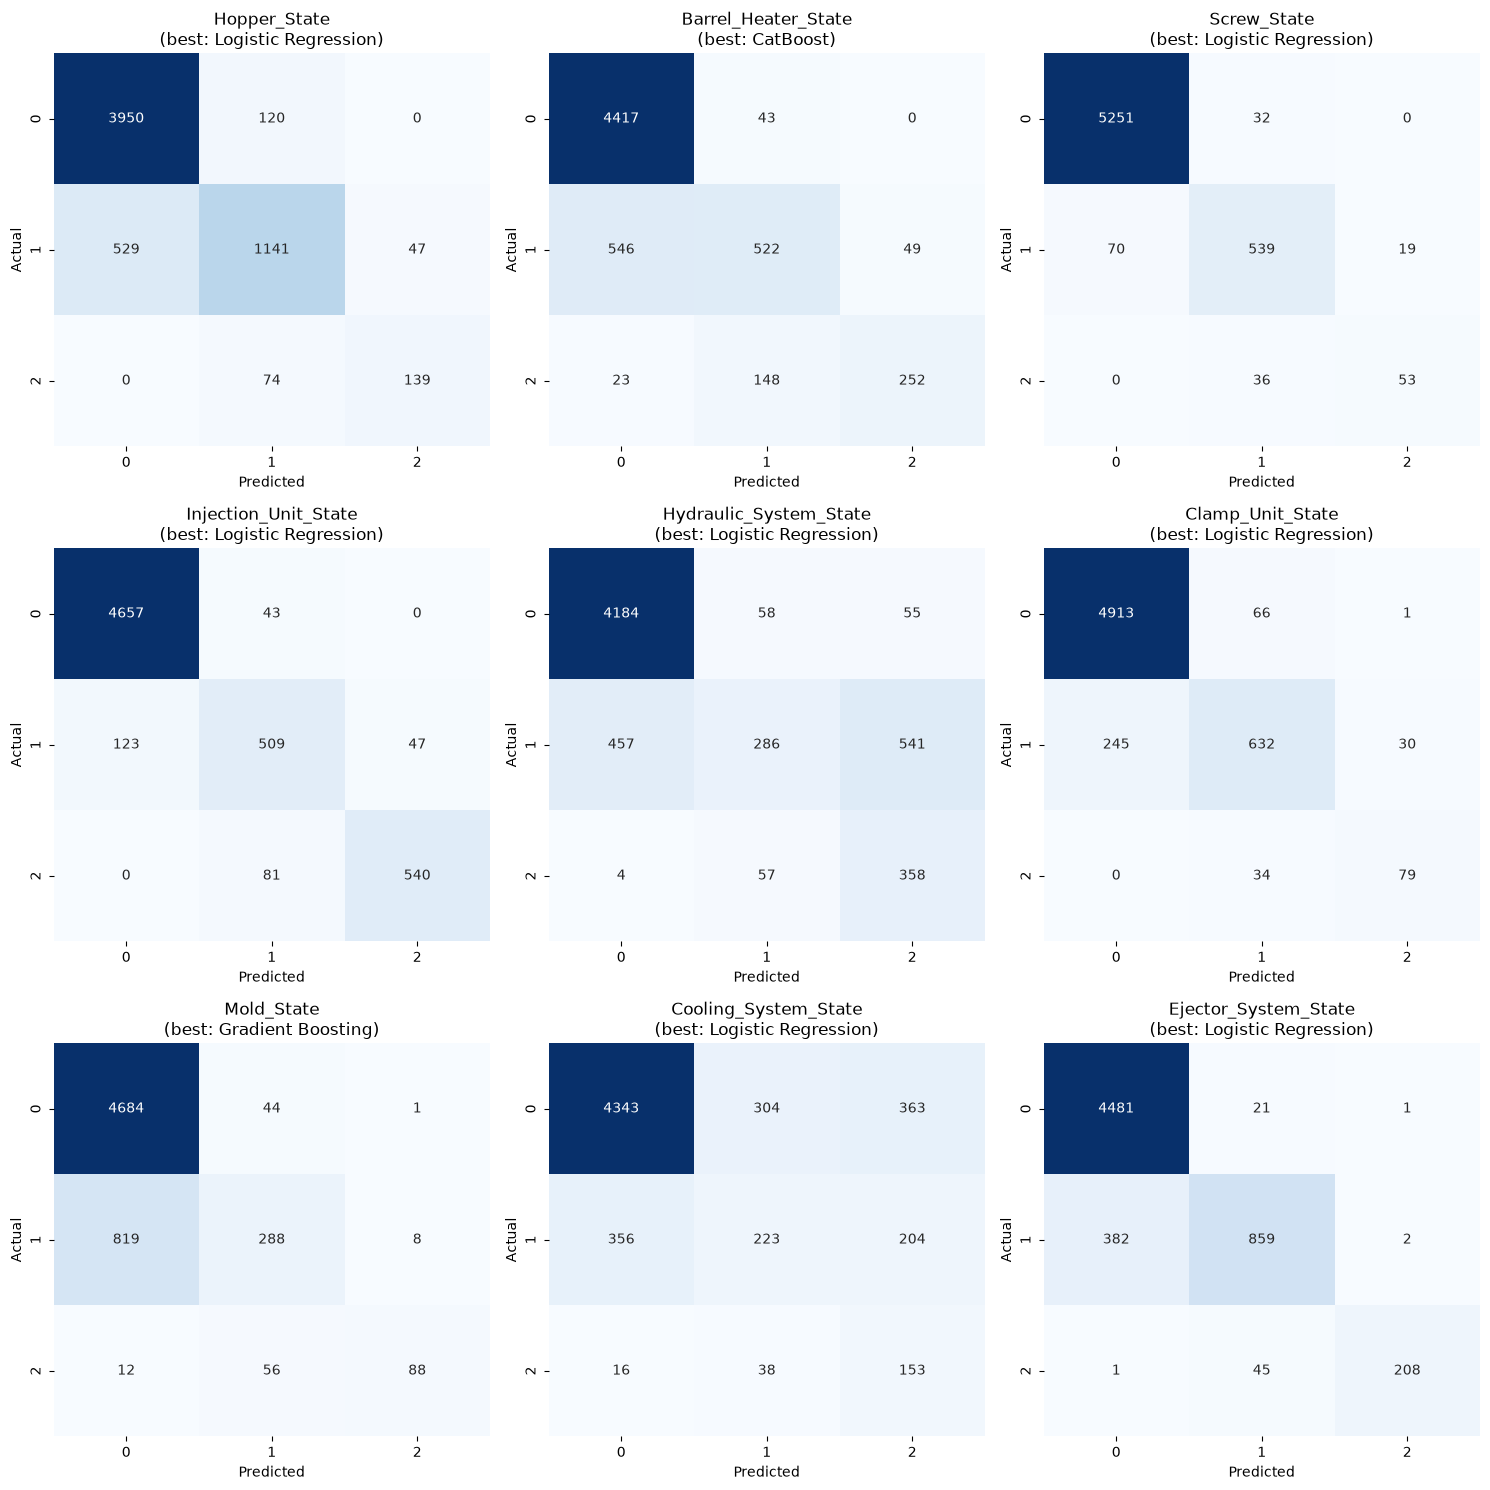

In [34]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(3, 3, figsize=(15, 15))

for ax, col in zip(axes.flat, target):
    best_model_name = best_model_per_target.loc[col, 'Model']
    model = get_classifiers()[best_model_name]
    model.fit(X_train, train_df[col])
    y_pred = np.asarray(model.predict(X_test)).reshape(-1)
    cm = confusion_matrix(test_df[col], y_pred, labels=[0, 1, 2])

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=[0, 1, 2], yticklabels=[0, 1, 2], ax=ax)
    ax.set_title(f'{col}\n(best: {best_model_name})')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()